In [1]:
import os
import time
import json
import torch
import numpy as np
from params import *
from Helpers import *
from TurPy import *
from PIL import Image

import matplotlib.pyplot as plt

In [ ]:
# Set all ranges to test
ranges = torch.linspace(10, 5000, 2)  # vector of all MAX ranges I care about
range_step = 1  # step size in m between phase screens

# Determine MAXIMUM waist for simulation
A = 1e-12
R = torch.linspace(0, ranges.max(), int(ranges.max()/range_step))
Cn2 = generate_oneway_trip_hv_model(A, 21, R)
wavelength = 1064e-9

# Calculate rytov variance
rytov = 3.27 * (2 * np.pi / wavelength) ** (7 / 6) * ranges.max() ** (5 / 6) *  torch.trapz(Cn2 * (1 - R / R.max()) ** (5 / 3), R)

# make params
params = make_params()

# setup the beam
theta = 0.05e-3  # divergence angle in mrad
w = wavelength / (torch.pi * theta)  # need to sample the gaussian
w_fs =  np.sqrt(w**2 + (theta*R.max())**2)
fres_ratio = (2 * R.max() / ((2*torch.pi/wavelength) * w_fs ** 2))  # fresnel ratio
w_turb = w_fs * np.sqrt(1 + 4/3 * rytov**(6/5) * fres_ratio)  # strong model assumption

print(w_fs, w_turb)

 # need to reach the turbulence waist
pixel_size = w/4  # MUST BE SMALLER THAN WAIST/2
grid_size = 2 * int(np.maximum(2**9, 2.5*w_turb//pixel_size) / 2)  # MUST BE BIGGER THAN PROJECTED WIDTH - make even
print(grid_size)

x = torch.linspace(-grid_size / 2, grid_size / 2, grid_size) * pixel_size
y = torch.linspace(-grid_size / 2, grid_size / 2, grid_size) * pixel_size
X, Y = torch.meshgrid(x, y)

print(f"Rytov Variance along path {rytov}")

# define a Gaussian beam
amplitude = torch.exp(- (X**2 + Y**2) / w**2)

# update params
params = make_params()
params["field_size"] = (grid_size, grid_size)
params["dx"] = pixel_size
params["wavelength"] = wavelength
params["screen_evolution"] = "static" 
params["wind_vec"] = [0, 0]
params["subharmonics"] = False
params["absorb_boundary"] = False



tensor(0.2501) tensor(0.4462)
658


C:\Users\jgreene97\AppData\Local\Temp\ipykernel_27056\3823602536.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  w_fs =  np.sqrt(w**2 + (theta*R.max())**2)
C:\Users\jgreene97\AppData\Local\Temp\ipykernel_27056\3823602536.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  w_turb = w_fs * np.sqrt(1 + 4/3 * rytov**(6/5) * fres_ratio)  # strong model assumption
C:\Users\jgreene97\AppData\Local\Temp\ipykernel_27056\3823602536.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  grid_size = 2 * int(np.maximum(2**9, 2.5*w_turb//pixel_size) / 2)  # MUST BE BIGGER THAN PROJECTED WIDTH - make even
c:\Users\jgreene97\Desktop\WaveTorch\.venv\lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an u

4999
torch.Size([4999]) torch.Size([4999])


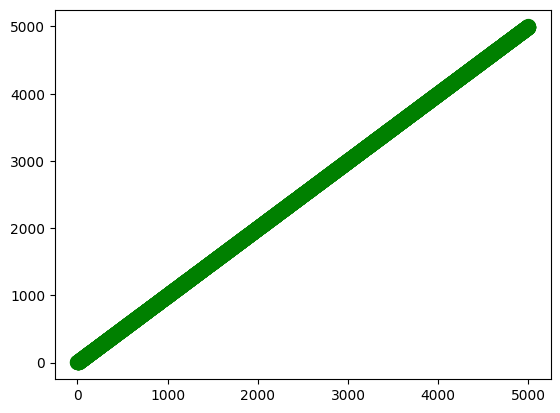

In [3]:
dr, r0 = calculate_path(params, R, Cn2, method='none')
print(len(r0))
R = torch.cumsum(dr, dim=0)
print(r0.size(), R.size())
# plt.scatter(r0, R, s=100, c='green')

plt.scatter(range(0, len(R)), R, s=100, c='green')

In [4]:
wt = TurPy(params=params)

print(wt.boundary)

None


device = cuda
1e-12 0
maximum step size support by this simulation is = 1330.053244155831 m
0


C:\Users\jgreene97\AppData\Local\Temp\ipykernel_27056\3506583173.py:36: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  fs[a_ind, r_ind] =  np.sqrt(w**2 + (theta*R.max())**2)
C:\Users\jgreene97\AppData\Local\Temp\ipykernel_27056\3506583173.py:51: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rr = np.sqrt(wt.xx.cpu()**2 + wt.yy.cpu()**2)
C:\Users\jgreene97\AppData\Local\Temp\ipykernel_27056\3506583173.py:63: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  turb[a_ind, r_ind] = fs[a_ind, r_ind] * np.sqrt(1 + 4/3 * rytov**(6/5) * fres_ratio)  # strong model assumption


500
1000
1500
2000
2500
3000
3500
4000


C:\Users\jgreene97\AppData\Local\Temp\ipykernel_27056\3506583173.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


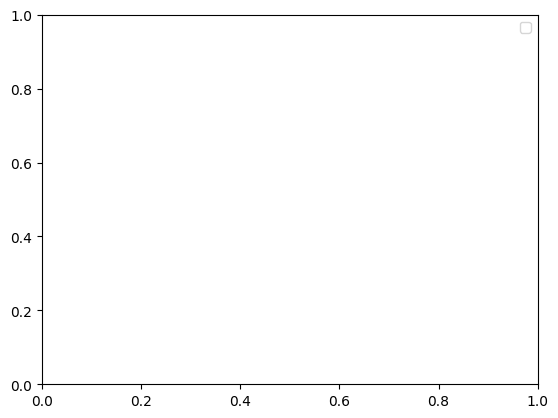

1e-12 1
maximum step size support by this simulation is = 1330.053244155831 m


C:\Users\jgreene97\AppData\Local\Temp\ipykernel_27056\3506583173.py:103: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rr = np.sqrt(wt.xx.cpu()**2 + wt.yy.cpu()**2)


0
500
1000
1500
2000
2500
3000
3500
4000


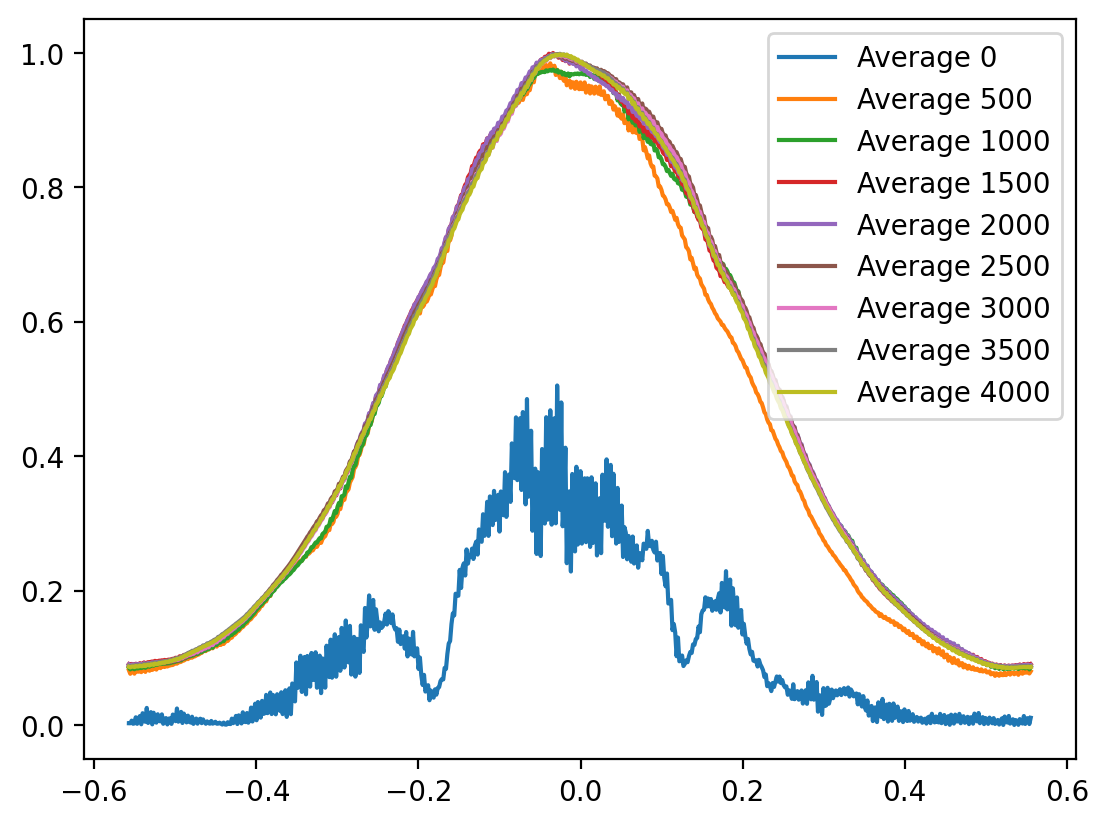

In [8]:
# do the averaging
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'device = {device}')
num_av = 4000
A_vec = np.logspace(-12, -11, 1)

# Preallocate results
fs = torch.zeros(len(A_vec), len(ranges))
turb = torch.zeros(len(A_vec), len(ranges))
fs_sim = torch.zeros(len(A_vec), len(ranges))
turb_sim = torch.zeros(len(A_vec), len(ranges))
turb_sim_av = torch.zeros(len(A_vec), len(ranges))
rytov_sim = torch.zeros(len(A_vec), len(ranges))

for a_ind in range(0, len(A_vec)):
    A = A_vec[a_ind]
    # Do the sweep
    for r_ind in range(0, len(ranges)):
        print(A, r_ind)
        # Reset output for averaging
        output = torch.zeros((wt.xx.size()))
        
        # Get the current range and setup R
        r_vec = ranges[r_ind]
        R = torch.linspace(0, r_vec, int(r_vec.max()/0.1))

        Cn2 = generate_oneway_trip_hv_model(A, 21, R)
        # print(R)

        # Get the wavetorch parameters
        dr, r0 = calculate_path(params=params, R=R, Cn2=Cn2, rytov_limit=1.0)

        # FREE SPACE #

        # THEORY: 
        fs[a_ind, r_ind] =  np.sqrt(w**2 + (theta*R.max())**2)

        # SIM:
        with torch.no_grad():
            free_space = wt.forward(amplitude.to(device), dr=dr, r0=None)

        # calculate
        I = torch.abs(free_space)**2

        # analyze results
        I_threshold = np.max(I.cpu().numpy()) * np.exp(-2)

        # Find the points where the intensity crosses the \(1/e^2\) threshold
        indices = np.where(I.cpu().numpy() < I_threshold)

        rr = np.sqrt(wt.xx.cpu()**2 + wt.yy.cpu()**2)
        rr[I.cpu().numpy() < I_threshold] = 0

        fs_sim[a_ind, r_ind] = rr.max()


        # TURBULENCE #

        # THEORY:
        rytov = 3.27 * (2 * np.pi / wavelength) ** (7 / 6) * R.max() ** (5 / 6) *  torch.trapz(Cn2 * (1 - R / R.max()) ** (5 / 3), R)
        rytov_sim[a_ind, r_ind] = rytov
        fres_ratio = (2 * R.max() / ((2*torch.pi/wavelength) * fs[a_ind, r_ind] ** 2))  # fresnel ratio
        turb[a_ind, r_ind] = fs[a_ind, r_ind] * np.sqrt(1 + 4/3 * rytov**(6/5) * fres_ratio)  # strong model assumption

        # SIM:
        # Get averaged turbulent waist
        if r_ind == len(ranges) - 1:
            plt.figure(dpi=200)
        for i in range(0, num_av+1):
            # print(i)
            start = time.time()
            with torch.no_grad():
                tmp = wt.forward(amplitude.to(device), dr=dr, r0=r0)
            end = time.time()   
            # average the intensity
            output += torch.abs(tmp.cpu())**2

            if i % 500 == 0:
                print(i)
                # Plot a line profile
                if r_ind == len(ranges) - 1:
                    plt.plot(wt.xx[:, 0].cpu(), output[grid_size//2, :] / (output.max()), label=f"Average {i}")
                    # Save results
                    tmp = output / output.max() * 256
                    img = Image.fromarray(tmp.cpu().numpy().astype(np.uint8))

                    # Save the image
                    img.save(f"output_image_{i}.png")

        
        plt.legend()
        plt.show()

        # Average and determine cutoff
        I = output / num_av

        # analyze results
        I_threshold = np.max(I.cpu().numpy()) * np.exp(-2.0)

        # Find the points where the intensity crosses the \(1/e^2\) threshold
        indices = np.where(I.cpu().numpy() < I_threshold)

        rr = np.sqrt(wt.xx.cpu()**2 + wt.yy.cpu()**2)
        rr[I.cpu().numpy() < I_threshold] = 0

        turb_sim[a_ind, r_ind] = rr.max()
        turb_sim_av[a_ind, r_ind] = np.mean(rr.max(axis=0))

        # TODO: ADD IN SCINTILLATION STATISTICS AND COMPARE TO THE THEORY OF THE TEXTBOOK (WHEN IN DOUBT ASK JOE/CHRIS V)

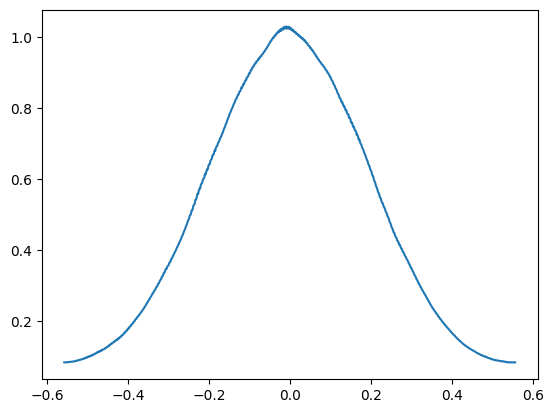

In [6]:
plt.figure()
plt.plot(wt.xx[:, 0].cpu(), output[grid_size//2, :])

IndexError: index -16 is out of bounds for dimension 0 with size 2

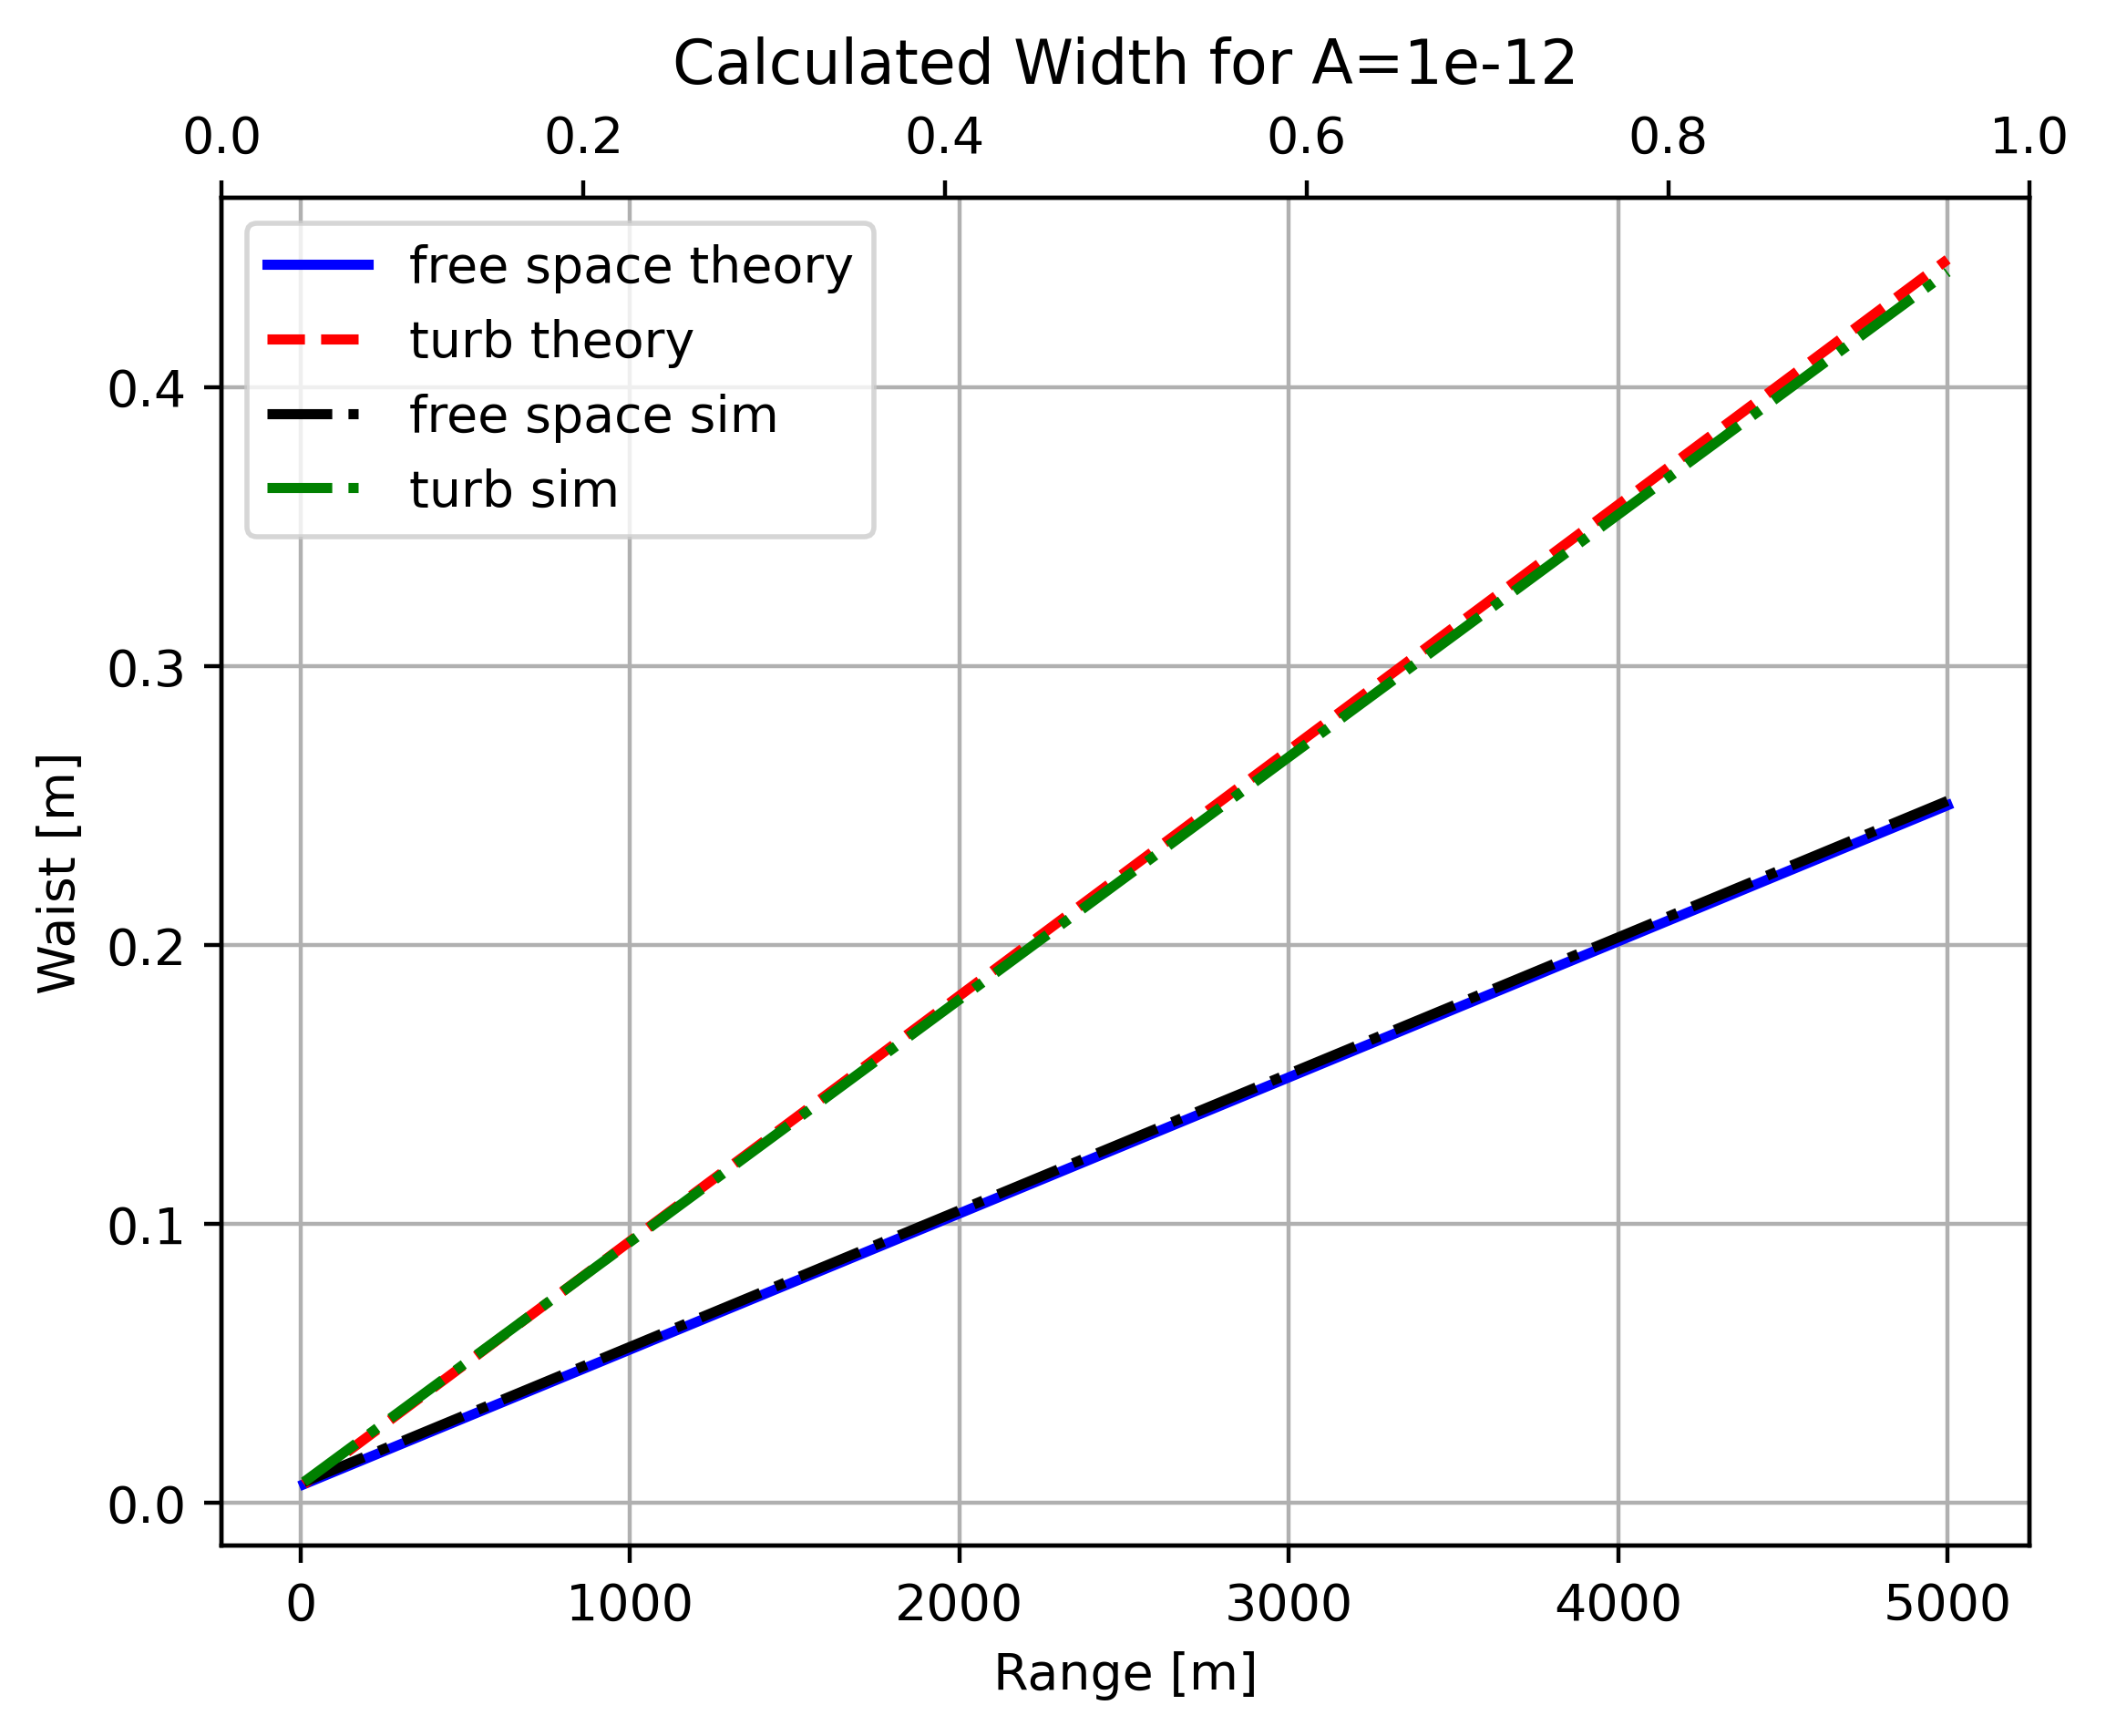

In [7]:
cwd = os.getcwd()
savedir = os.path.join(cwd, f'trial {time.time()}')
os.mkdir(savedir)

# # Plot and save results
# for a_ind in range(0, len(A_vec)):
#     A = A_vec[a_ind]
#     plt.figure()
#     plt.plot(ranges, fs[a_ind,:], linewidth=2, color='b', label='free space theory')
#     plt.plot(ranges, turb[a_ind,:], linewidth=2, linestyle = '--', color='r', label='turb theory')
#     plt.plot(ranges, fs_sim[a_ind,:], linewidth=2, linestyle='-.', color='k', label='free space sim')
#     plt.plot(ranges, turb_sim[a_ind,:], linewidth=2, linestyle='-.', color='g', label='turb sim')
#     #plt.plot(ranges, turb_sim_av[a_ind,:], linewidth=2, linestyle='-.', color='y', label='turb sim')
#     plt.xlabel('Range [m]')
#     plt.ylabel('Waist [m]')
#     plt.title(f'Calculated Width for A={A}')
#     plt.legend()
#     plt.savefig(os.path.join(savedir, f'trial_{a_ind}'))

entries = [0, -16, -11, -6, -1]

#entries = [0, -1]

for a_ind in range(0, len(A_vec)):
    plt.figure(dpi=400)
    ax1 = plt.gca()
    ax1.plot(ranges, fs[a_ind,:], linewidth=2, color='b', label='free space theory')
    ax1.plot(ranges, turb[a_ind,:], linewidth=2, linestyle = '--', color='r', label='turb theory')
    ax1.plot(ranges, fs_sim[a_ind,:], linewidth=2, linestyle='-.', color='k', label='free space sim')
    ax1.plot(ranges, turb_sim[a_ind,:], linewidth=2, linestyle='-.', color='g', label='turb sim')
    #plt.plot(ranges, turb_sim_av[a_ind,:], linewidth=2, linestyle='-.', color='y', label='turb sim')
    ax1.set_xlabel('Range [m]')
    ax1.set_ylabel('Waist [m]')
    ax1.set_title(f'Calculated Width for A={A_vec[a_ind]}')
    ax1.legend()
    # ax1.legend()
    ax1.grid(True)

    ax2 = ax1.twiny() 
    ax2.set_xlim()
    ax2.set_xticks(rytov_sim[a_ind, entries]) # Assumed rytov_vec matches your primary data
    ax2.set_xticklabels([f'{ryt:.1e}' for ryt in rytov_sim[a_ind, entries]])
    ax2.set_xlabel('Rytov Variance ($σ_R^2$)') # Optional: label for the top axi

    plt.tight_layout()
    #plt.savefig(os.path.join(folder_name, 'DER_atmosphere2.png'), dpi=300, bbox_inches="tight")
    plt.show()

# Plot and save raw data for later inspection
np.savetxt(os.path.join(savedir, 'output_free_space.csv'), fs.cpu().numpy(), delimiter=',')
np.savetxt(os.path.join(savedir, 'output_turb.csv'), turb.cpu().numpy(), delimiter=',')
np.savetxt(os.path.join(savedir, 'output_free_space_sim.csv'), fs.cpu().numpy(), delimiter=',')
np.savetxt(os.path.join(savedir, 'output_turb_sim.csv'), turb.cpu().numpy(), delimiter=',')
np.savetxt(os.path.join(savedir, 'ranges.csv'), ranges.cpu().numpy(), delimiter=',')

params['theta'] = theta
params['range_step'] = range_step
params['A_vec'] = list(A_vec)

file_path = os.path.join(savedir, 'params.txt')
with open(file_path, "w") as file:
    json.dump(params, file, indent=4)

In [ ]:
# Determine accuracy


In [ ]:
norm = lambda x: x / np.max(x)

# Display the figure
plt.figure()
plt.plot(x, norm(np.abs(output[grid_size//2, :].cpu().numpy())))
plt.plot(x, norm(np.abs(free_space[grid_size//2, :].cpu().numpy())**2), linestyle='--')  # looks off because not exactly scaled correctly.

# Check the R array of the turbulent waist
plt.figure()
plt.imshow(output.cpu().numpy())

# tmp, tmp2 = torch.max(rr, axis=1)
# filtered = tmp[tmp!=0]
# print(torch.mean(filtered), torch.max(rr))

In [ ]:
# Make a final instance of the turbulent Gaussian
tmp = wt.forward(amplitude.to(device), dr=dr, r0=r0)
